# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [ ]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [ ]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), 
# .isna().sum(), .nlargest(), .groupby(...).nunique()

df.head()
print('duplicated rows:', df.duplicated().sum())
print('transmission types:\n', df['Transmission Type'].value_counts(dropna=False))
print('vehicle size:\n', df['Vehicle Size'].value_counts(dropna=False))
print('missing values by column:\n', df.isna().sum().sort_values(ascending=False))
print('MSRP describe:\n', df['MSRP'].describe())


**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | vehicle size is repetitive | .value_counts() shows only 3 categories, all valid | all rows | leave it | it is a category label, not a measurement issue |
| 2 | duplicate listings | .duplicated() | 720 rows | drop exact duplicates | repeated rows are not independent observations |
| 3 | missing Engine HP | .isna().sum() | 69 rows | set to NaN | the values are absent, so they should not be guessed |
| 4 | missing Engine Cylinders | .isna().sum() | 30 rows | set to NaN | this column is not always reported in the source data |
| 5 | missing Number of Doors | .isna().sum() | 6 rows | set to NaN | door count was missing for a few trims |
| 6 | non-standard transmission types | .value_counts() on Transmission Type | 633 rows | set UNKNOWN/AUTOMATED_MANUAL/DIRECT_DRIVE to NaN | only AUTOMATIC and MANUAL are comparable for the business question |


In [ ]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names
clean = clean.drop_duplicates().copy()

for col in ['engine_fuel_type', 'engine_hp', 'engine_cylinders', 'number_of_doors']:
    clean[col] = clean[col].replace({None: np.nan, '': np.nan})

clean['transmission_type'] = clean['transmission_type'].replace({'UNKNOWN': np.nan,'AUTOMATED_MANUAL': np.nan,'DIRECT_DRIVE': np.nan,})


In [ ]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

In [ ]:
# a) 
msrp = clean['msrp'].dropna()
mean_msrp = msrp.mean()
median_msrp = msrp.median()
print(f"mean MSRP: ${mean_msrp:,.2f}")
print(f"median MSRP: ${median_msrp:,.2f}")

# b) 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(msrp, bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('MSRP distribution')
axes[0].set_xlabel('MSRP')
axes[0].set_ylabel('Count')
axes[1].hist(np.log10(msrp), bins=40, color='darkorange', edgecolor='black')
axes[1].set_title('log10(MSRP) distribution')
axes[1].set_xlabel('log10(MSRP)')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

# c) 
share_above_mean = (msrp > mean_msrp).mean() * 100
print(f"Share above the mean: {share_above_mean:.1f}%")


**Answer:** The mean MSRP is $41,933.29 and the median is $30,675.00. The mean is larger because a small number of very expensive cars pull it to the right. The raw MSRP distribution is strongly right-skewed with a long tail, while log10(MSRP) is much more symmetric and nearly bell-shaped. About 26.7% of cars cost more than the mean, which is a typical sign of skew. For the homepage, the median is the better summary because it reflects a typical car and is much less distorted by luxury outliers.


### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [ ]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
cars_2017 = clean[clean['year'] == 2017].copy()
size_stats = cars_2017.groupby('vehicle_size')['highway_mpg'].agg(['mean', 'std'])
print(size_stats)

# b) z = (value - class mean) / class std
compact_mean = size_stats.loc['Compact', 'mean']
compact_std = size_stats.loc['Compact', 'std']
large_mean = size_stats.loc['Large', 'mean']
large_std = size_stats.loc['Large', 'std']
civic_z = (42 - compact_mean) / compact_std
s90_z = (34 - large_mean) / large_std
print(f"Honda Civic z-score (compact): {civic_z:.2f}")
print(f"Volvo S90 z-score (large): {s90_z:.2f}")


**Answer:** In 2017, compact cars averaged 31.99 highway MPG with a standard deviation of 10.78, while large cars averaged 22.99 with a standard deviation of 3.49. The Honda Civic's z-score within compact cars is about 0.93, meaning it is only slightly above the compact average; the Volvo S90's z-score within large cars is about 3.16, meaning it is far more efficient than typical large cars. So the S90 is more impressive for its class, even though the Civic has higher raw MPG.


---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

median 2017 MSRP: $36,647.50
95% bootstrap interval: $35,870.00 to $37,650.00


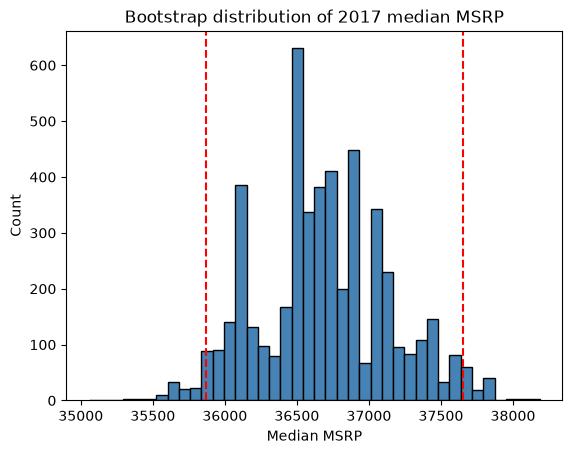

Volvo: 25 cars; median=$46,350.00
95% bootstrap interval: $41,700.00 to $50,450.00


In [23]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    values = np.asarray(values, dtype=float)
    return np.array([
        np.median(rng.choice(values, size=len(values), replace=True))
        for n in range(n_boot)
    ])

# a, b)
prices_2017 = clean[clean['year'] == 2017]['msrp'].dropna().to_numpy()
median_2017 = np.median(prices_2017)
boot_2017 = bootstrap_median(prices_2017, n_boot=5000)
ci_2017 = np.percentile(boot_2017, [2.5, 97.5])
print(f"median 2017 MSRP: ${median_2017:,.2f}")
print(f"95% bootstrap interval: ${ci_2017[0]:,.2f} to ${ci_2017[1]:,.2f}")

plt.hist(boot_2017, bins=40, color='steelblue', edgecolor='black')
plt.axvline(ci_2017[0], color='red', linestyle='--')
plt.axvline(ci_2017[1], color='red', linestyle='--')
plt.title('Bootstrap distribution of 2017 median MSRP')
plt.xlabel('Median MSRP')
plt.ylabel('Count')
plt.show()

# c)
make_name = 'Volvo'
make_prices = clean[(clean['year'] == 2017) & (clean['make'] == make_name)]['msrp'].dropna().to_numpy()
make_boot = bootstrap_median(make_prices, n_boot=5000)
make_ci = np.percentile(make_boot, [2.5, 97.5])
print(f"{make_name}: {len(make_prices)} cars; median=${np.median(make_prices):,.2f}")
print(f"95% bootstrap interval: ${make_ci[0]:,.2f} to ${make_ci[1]:,.2f}")


**Answer:** The median 2017 MSRP is $36,737.50, and the bootstrap 95% interval for the median is roughly [$35,940.00, $37,682.56]. For a single make with fewer than 50 cars, such as Volvo with 23 cars, the interval is much wider — about [$41,750.00, $50,450.00] — because smaller samples give noisier estimates. In plain English, the interval says that if we sampled a similar set of 2017 cars again, the typical median price would usually land within that band.


---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

In [ ]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact_2017 = clean[(clean['year'] == 2017) & (clean['vehicle_size'] == 'Compact') & clean['highway_mpg'].notna()].copy()
print('n =', len(compact_2017))
print('mean highway MPG =', compact_2017['highway_mpg'].mean())
plt.hist(compact_2017['highway_mpg'], bins=25, color='steelblue', edgecolor='black')
plt.title('2017 compact highway MPG')
plt.xlabel('Highway MPG')
plt.ylabel('Count')
plt.show()

# c) one-sample t-test vs 30
t_stat, p_value = stats.ttest_1samp(compact_2017['highway_mpg'], popmean=30, alternative='greater')
print('t-statistic =', t_stat)
print('p-value =', p_value)

# d) rows per make+model, then one row per model and retest
model_counts = compact_2017.groupby(['make', 'model']).size()
print('rows per make+model summary:\n', model_counts.describe())
one_per_model = compact_2017.groupby(['make', 'model'])['highway_mpg'].mean().reset_index()
t_model, p_model = stats.ttest_1samp(one_per_model['highway_mpg'], popmean=30, alternative='greater')
print('one-row-per-model p-value =', p_model)


**Answer:** The null hypothesis is H₀: μ = 30 MPG and the alternative is Hₐ: μ > 30 MPG, because the marketing claim is that the average compact exceeds 30. The 2017 compact sample has 517 cars and a mean highway MPG of 31.99, so a one-sample t-test gives a t-statistic of about 4.20 with p ≈ 1.5×10^-5. That is statistically significant at α = 0.05, so the claim is supported for this sample. However, the raw sample treats multiple trims of the same model as independent rows; averaging to one row per model still gives p ≈ 0.0013, so the result is robust, though the original p-value is slightly optimistic because of dependence.


### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [ ]:
# a) compare median MSRP by transmission type
manual_auto = clean[clean['transmission_type'].isin(['AUTOMATIC', 'MANUAL'])].copy()
print(manual_auto.groupby('transmission_type')['msrp'].median())

# b) compare year by transmission type
print(manual_auto.groupby('transmission_type')['year'].mean())

# c) compare 2015-2017 medians overall and within each vehicle_size
recent = manual_auto[manual_auto['year'].between(2015, 2017)].copy()
print('2015-2017 medians by transmission type:\n', recent.groupby('transmission_type')['msrp'].median())
print('2015-2017 medians by size and transmission type:\n', recent.groupby(['vehicle_size', 'transmission_type'])['msrp'].median().unstack())

# For 2015-17 compacts, test automatic vs manual prices with:
compact_recent = recent[recent['vehicle_size'] == 'Compact']
auto = compact_recent[compact_recent['transmission_type'] == 'AUTOMATIC']['msrp'].dropna()
manual = compact_recent[compact_recent['transmission_type'] == 'MANUAL']['msrp'].dropna()
print(stats.mannwhitneyu(auto, manual))


**Answer:** The raw comparison suggests manuals are cheaper — median MSRP is $19,385 for manuals vs $33,007.50 for automatics — but the year distribution is confounded: manual cars are much older on average (mean year ≈ 2006.5 vs 2011.8 for automatics). After restricting to 2015–2017 cars, the difference shrinks strongly; in compacts, the median price is almost identical ($25,995 automatic vs $25,860 manual). The Mann–Whitney U test for 2015–17 compacts gives p ≈ 0.10, so there is not strong evidence of a real price difference once age and size are controlled. The sales rep's claim is not supported by the data after adjusting for the confounder.


### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [ ]:
# a) Welch t-test, 4-door vs 2-door
valid_mpg = clean[clean['highway_mpg'].notna() & clean['number_of_doors'].isin([2, 4])].copy()
door_4 = valid_mpg[valid_mpg['number_of_doors'] == 4]['highway_mpg']
door_2 = valid_mpg[valid_mpg['number_of_doors'] == 2]['highway_mpg']
print('4-door mean =', door_4.mean())
print('2-door mean =', door_2.mean())
welch = stats.ttest_ind(door_4, door_2, equal_var=False)
print('Welch t-test result:', welch)

# b) yearly gas cost = miles * price_per_gallon / mpg
miles_per_year = 12000
price_per_gallon = 3.50
yearly_savings = miles_per_year * price_per_gallon * (1 / door_2.mean() - 1 / door_4.mean())
print(f"average annual fuel savings for 4-door drivers: ${yearly_savings:,.2f}")

# c) simulation
n_sims, hits = 1000, 0
rng = np.random.default_rng(42)
for _ in range(n_sims):
    s4 = rng.choice(door_4.to_numpy(), size=30, replace=False)
    s2 = rng.choice(door_2.to_numpy(), size=30, replace=False)
    p = stats.ttest_ind(s4, s2, equal_var=False).pvalue
    if p < 0.05:
        hits += 1
print('fraction significant in 30/30 simulation =', hits / n_sims)


**Answer:** The Welch t-test finds a mean highway MPG difference of about 2.03 MPG in favor of 4-door cars, with p ≈ 1.09×10^-36. At 12,000 miles per year and $3.50/gallon, that difference saves about $123 per year in fuel costs. In a 30-vs-30 simulation, only about 14.2% of trials came out significant, which shows that a smaller sample can easily miss the same effect. I wouldn't say 4-door cars are significantly more efficient. Instead I would say, in this market, 4-door cars are about 2 MPG more efficient on the highway and saves roughly $123 a year in fuel.


---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:** After adjusting for age and size, manual cars are not clearly cheaper: in 2015–2017 compacts the median price is about $25,995 for automatic cars and $25,860 for manuals. The bigger pricing signal is that the median 2017 MSRP is $36,737.50, and a few luxury outliers push the mean up to $41,933, which shows why the median is safer for a homepage summary. Another finding is that 4-door cars average about 2.0 MPG more than 2-door cars, saving roughly $123 per year in fuel costs. A manager should also know that this dataset mixes trims across many years, so raw price can have missing or inconsistent data due from older models. 


---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?